Normalization - Scaling Filter on Best Two Resampling Methods

In [4]:
from pathlib import Path
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [5]:
BASE = Path('..').resolve()
PROCESSED_DATA_DIR = BASE / 'data' / 'processed'
IMBALANCED_DATA_DIR = BASE / 'data' / 'imbalanced'
NORMALIZED_DATA_DIR = BASE / 'data' / 'normalized'
REPORTS_DIR = BASE / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
for folder in [NORMALIZED_DATA_DIR, REPORTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = [
    'inter_api_access_duration(sec)', 'api_access_uniqueness', 'sequence_length(count)',
    'vsession_duration(min)', 'ip_type', 'num_sessions', 'num_users',
    'num_unique_apis', 'source', 'failed_auth_count', 'token_reuse_ratio',
    'status_4xx_ratio', 'status_5xx_ratio'
]
TARGET_COLUMN = 'attack_class'
CATEGORICAL_COLUMNS = ['ip_type', 'source']
NUMERICAL_COLUMNS = [col for col in FEATURE_COLUMNS if col not in CATEGORICAL_COLUMNS]

In [11]:
evaluation_test_features = pd.read_csv(PROCESSED_DATA_DIR / 'X_test.csv')
evaluation_test_labels_df = pd.read_csv(PROCESSED_DATA_DIR / 'y_test.csv')
evaluation_test_labels = (
    evaluation_test_labels_df[TARGET_COLUMN]
    if TARGET_COLUMN in evaluation_test_labels_df.columns
    else evaluation_test_labels_df.iloc[:, 0]
)

stage_a_top2_candidates = [
    REPORTS_DIR / '02_resampling_top2_resampling.csv',
    REPORTS_DIR / 'stage_a_top2_resampling.csv'
]
stage_a_top2_path = next((p for p in stage_a_top2_candidates if p.exists()), None)
if stage_a_top2_path is None:
    raise FileNotFoundError('Missing top-2 resampling file. Expected one of: 02_resampling_top2_resampling.csv, stage_a_top2_resampling.csv')
stage_a_selection_df = pd.read_csv(stage_a_top2_path)
if 'best_two_resampling_methods' in stage_a_selection_df.columns:
    selected_methods_raw = stage_a_selection_df.iloc[0]['best_two_resampling_methods']
elif 'top2_resampling' in stage_a_selection_df.columns:
    selected_methods_raw = stage_a_selection_df.iloc[0]['top2_resampling']
elif {'best_method_rank_1', 'best_method_rank_2'}.issubset(stage_a_selection_df.columns):
    selected_methods_raw = f"{stage_a_selection_df.iloc[0]['best_method_rank_1']},{stage_a_selection_df.iloc[0]['best_method_rank_2']}"
else:
    selected_methods_raw = f"{stage_a_selection_df.iloc[0]['top1']},{stage_a_selection_df.iloc[0]['top2']}"

best_two_resampling_methods = [token.strip() for token in str(selected_methods_raw).split(',') if token.strip()]

allowed_resampling_methods = {'none', 'oversampling', 'undersampling', 'smote'}
best_two_resampling_methods = [m for m in best_two_resampling_methods if m in allowed_resampling_methods]
if not best_two_resampling_methods:
    raise ValueError('No valid Stage A resampling methods found after filtering allowed set.')

print('--- Input Diagnostics ---')
print('evaluation_test_features shape:', evaluation_test_features.shape)
print('evaluation_test_labels shape :', evaluation_test_labels.shape)
print('')
print('Selected resampling methods :', best_two_resampling_methods)
print('')
print('Test class distribution:')
print(evaluation_test_labels.value_counts())

--- Input Diagnostics ---
evaluation_test_features shape: (1200, 13)
evaluation_test_labels shape : (1200,)

Selected resampling methods : ['undersampling', 'oversampling']

Test class distribution:
attack_class
normal         635
bruteforce     214
flood          188
token_abuse    163
Name: count, dtype: int64


In [8]:
scaling_strategies = {
    'none': None,
    'minmax': MinMaxScaler(),
    'standard': StandardScaler(),
}

scaling_filter_results_rows = []

for resampling_method in best_two_resampling_methods:
    resampled_train_features = pd.read_csv(IMBALANCED_DATA_DIR / f'X_{resampling_method}.csv')
    # Backward compatibility: some Stage A outputs are already encoded with numeric headers.
    # Recover schema so ColumnTransformer can reliably select named columns.
    if not set(FEATURE_COLUMNS).issubset(set(resampled_train_features.columns)):
        if resampled_train_features.shape[1] >= len(FEATURE_COLUMNS):
            resampled_train_features = resampled_train_features.iloc[:, :len(FEATURE_COLUMNS)].copy()
            resampled_train_features.columns = FEATURE_COLUMNS
        else:
            missing = sorted(set(FEATURE_COLUMNS) - set(resampled_train_features.columns))
            raise ValueError(f"Resampled file for {resampling_method} is missing required columns: {missing}")
    resampled_train_labels_df = pd.read_csv(IMBALANCED_DATA_DIR / f'y_{resampling_method}.csv')
    resampled_train_labels = (
        resampled_train_labels_df[TARGET_COLUMN]
        if TARGET_COLUMN in resampled_train_labels_df.columns
        else resampled_train_labels_df.iloc[:, 0]
    )

    for scaling_name, scaling_transformer in scaling_strategies.items():
        if scaling_transformer is None:
            numerical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
        else:
            numerical_pipeline = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', scaling_transformer),
            ])

        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ])

        feature_preprocessor = ColumnTransformer([
            ('num', numerical_pipeline, NUMERICAL_COLUMNS),
            ('cat', categorical_pipeline, CATEGORICAL_COLUMNS),
        ])

        transformed_train_features = feature_preprocessor.fit_transform(resampled_train_features)
        transformed_test_features = feature_preprocessor.transform(evaluation_test_features)

        transformed_train_dense = (
            transformed_train_features.toarray()
            if hasattr(transformed_train_features, 'toarray')
            else transformed_train_features
        )
        transformed_test_dense = (
            transformed_test_features.toarray()
            if hasattr(transformed_test_features, 'toarray')
            else transformed_test_features
        )

        transformed_output_dir = NORMALIZED_DATA_DIR / f'{resampling_method}_{scaling_name}'
        transformed_output_dir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(transformed_train_dense).to_csv(transformed_output_dir / 'X_train.csv', index=False)
        pd.DataFrame(transformed_test_dense).to_csv(transformed_output_dir / 'X_test.csv', index=False)

        random_forest_baseline = RandomForestClassifier(
            n_estimators=220,
            random_state=42,
            class_weight='balanced',
        )
        
        random_forest_baseline.fit(transformed_train_features, resampled_train_labels)
        predicted_labels = random_forest_baseline.predict(transformed_test_features)

        scaling_filter_results_rows.append({
            'stage': 'B_scaling_filter',
            'resampling': resampling_method,
            'scaling': scaling_name,
            'model': 'RandomForest',
            'accuracy': round(accuracy_score(evaluation_test_labels, predicted_labels), 4),
            'macro_precision': round(precision_score(evaluation_test_labels, predicted_labels, average='macro', zero_division=0), 4),
            'macro_recall': round(recall_score(evaluation_test_labels, predicted_labels, average='macro', zero_division=0), 4),
            'macro_f1': round(f1_score(evaluation_test_labels, predicted_labels, average='macro', zero_division=0), 4),
        })

scaling_filter_results_df = pd.DataFrame(scaling_filter_results_rows).sort_values(
    ['macro_f1', 'macro_recall'],
    ascending=False,
)
scaling_filter_results_df.to_csv(REPORTS_DIR / '03_scaling_results.csv', index=False)

best_stage_b_row = scaling_filter_results_df.iloc[0]
best_preprocessing_combo_df = pd.DataFrame([
    {
        'best_resampling': best_stage_b_row['resampling'],
        'best_scaling': best_stage_b_row['scaling'],
    }
])
best_preprocessing_combo_df.to_csv(REPORTS_DIR / '03_scaling_best_combo.csv', index=False)

print('Scaling filter performance leaderboard:')
print(scaling_filter_results_df)
print('')
print('Best Stage B combination:')
print(best_preprocessing_combo_df)

Scaling filter performance leaderboard:
              stage     resampling   scaling         model  accuracy  \
0  B_scaling_filter  undersampling      none  RandomForest    0.9983   
1  B_scaling_filter  undersampling    minmax  RandomForest    0.9983   
2  B_scaling_filter  undersampling  standard  RandomForest    0.9983   
3  B_scaling_filter   oversampling      none  RandomForest    0.9967   
5  B_scaling_filter   oversampling  standard  RandomForest    0.9967   
4  B_scaling_filter   oversampling    minmax  RandomForest    0.9958   

   macro_precision  macro_recall  macro_f1  
0           0.9973        0.9973    0.9973  
1           0.9973        0.9973    0.9973  
2           0.9973        0.9973    0.9973  
3           0.9962        0.9941    0.9951  
5           0.9962        0.9941    0.9951  
4           0.9950        0.9925    0.9937  

Best Stage B combination:
  best_resampling best_scaling
0   undersampling         none


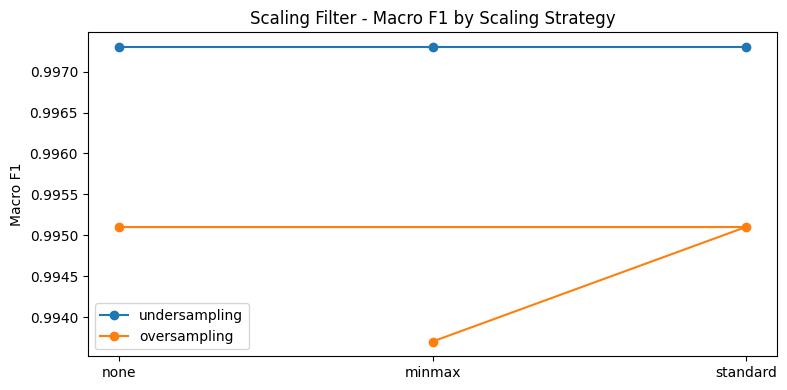

In [10]:
plt.figure(figsize=(8, 4))
for resampling_method in scaling_filter_results_df['resampling'].unique():
    method_slice = scaling_filter_results_df[scaling_filter_results_df['resampling'] == resampling_method]
    plt.plot(method_slice['scaling'], method_slice['macro_f1'], marker='o', label=resampling_method)

plt.title('Scaling Filter - Macro F1 by Scaling Strategy')
plt.ylabel('Macro F1')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_scaling.png', dpi=160)
plt.show()